In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.tools.managers.db_connector import DBConnection
from src.databases.bronze.aneel.config import YEARS

In [ ]:
def generate_query():
    """
    Generates a SQL query to retrieve energy consumption data for different years and months.
    The query joins multiple tables based on geographical equality and filters by specific conditions.
    """
    
    str_cols = ""
    str_join = ""
    str_where = ""
    for year in YEARS:
      table_alias = f"e{year}"
      base_table_alias = "e2017"
      year_alias = year - 2000
      for month in range(1, 13):
          month = str(month).zfill(2)  # Ensure month is two digits
          str_cols = ", \n".join([f"{table_alias}.ene_{month}_sum AS e_{month}_{year_alias}", str_cols])
      if year != 2017:
        str_join = " \n".join([f"JOIN infrastructure.aneel_join_{year} {table_alias} ON ST_Equals({base_table_alias}.geometry, {table_alias}.geometry)", str_join])
      str_where = " \n".join([f"{table_alias}.clas_sub = 'RE1' AND {table_alias}.company_file_ponnot = 'ENEL_SP - {year}-12-31.gdb.zip' AND", str_where])

    str_cols = str_cols[:-3]  # Remove the trailing comma and space
    str_where = str_where[:-6]  # Remove the trailing ' AND '
    query = f"""
    SELECT 
      e2017.geometry,
      {str_cols}
    FROM infrastructure.aneel_join_2017 e2017
      {str_join}
    WHERE {str_where}
    """
    return query

In [4]:
def generate_query(year:int):
    """
    Generates a SQL query to retrieve energy consumption data for different years and months.
    The query joins multiple tables based on geographical equality and filters by specific conditions.
    """
    
    str_cols = ""
    str_where = ""
    
    year_alias = year - 2000
    for month in range(1, 13):
            month = str(month).zfill(2)  # Ensure month is two digits
            str_cols = ", \n".join([f"ene_{month}_sum AS e_{month}_{year_alias}", str_cols])
    str_where = f"clas_sub = 'RE1' AND company_file_ponnot = 'ENEL_SP - {year}-12-31.gdb.zip'"

    str_cols = str_cols[:-3]  # Remove the trailing comma and space
    query = f"""
                    SELECT 
                    dist,
                    mun,
                    conj,
                    pn_con,
                    geometry,
                    {str_cols}
                    FROM infrastructure.aneel_join_{year}
                    WHERE {str_where}
                    """
    return query

In [6]:
for year in tqdm(YEARS, desc="Generating queries and saving data"):
   query = generate_query(year)
   with DBConnection("bronze") as conn:
      df = conn.query_database(query)
      df.to_csv(f"/home/yan/projetos/blog/spatiotemporal-notebooks/examples/exploratory_analysis/data/aneel_SP_points_energy_consumption_{year}.csv", index=False)

Generating queries and saving data: 100%|██████████| 7/7 [09:53<00:00, 84.83s/it] 


In [ ]:
mun = '3550308'
query = """
SELECT 
    a.hex_col, 
    a.energy_consumption_residencial_urbano as energy_consump_{year}
FROM infrastructure.aneel_join_{year} a 
WHERE cd_mun = '{mun}'
AND a.energy_consumption_residencial_urbano > 0
"""
df_final = None
for year in tqdm(YEARS, desc='Loading data from ANEEL'):
    with DBConnection("bronze") as conn:
        df_mun = conn.query_database(query.format(year=year, mun=mun)).set_index('hex_col')
    if year == YEARS[0]:
        df_final = df_mun.copy()
        continue
    
    df_final = pd.merge(
        df_final, # type: ignore
        df_mun, 
        how='outer', 
        left_index=True, 
        right_index=True, 
        suffixes=('', f'_{year}')
    )
df_final = df_final.fillna(0)   # type: ignore
df_final.to_csv(
    f'/home/yan/projetos/blog/spatiotemporal-notebooks/examples/exploratory_analysis/data/hexagon_grp_{mun}.csv',
    index_label='hex_col',
)

Loading data from ANEEL: 100%|██████████| 7/7 [00:02<00:00,  3.36it/s]


In [ ]:
query = """
select join_type, 
	SUM(ene_01_sum+
		ene_02_sum+
		ene_03_sum+
		ene_04_sum+
		ene_05_sum+
		ene_06_sum+
		ene_07_sum+
		ene_08_sum+
		ene_09_sum+
		ene_10_sum+
		ene_11_sum+
		ene_12_sum
		)  
from infrastructure.aneel_join_{year}
where company_file_ponnot = 'ENEL_SP - {year}-12-31.gdb.zip'
group by 1
"""
df_grp = []
for year in YEARS:
	with DBConnection("bronze") as conn:
		df = conn.query_database(query.format(year=year))
		df["year"] = year
		df_grp.append(df)
df_grp = pd.concat(df_grp, ignore_index=True)
df_grp = df_grp.fillna(0)

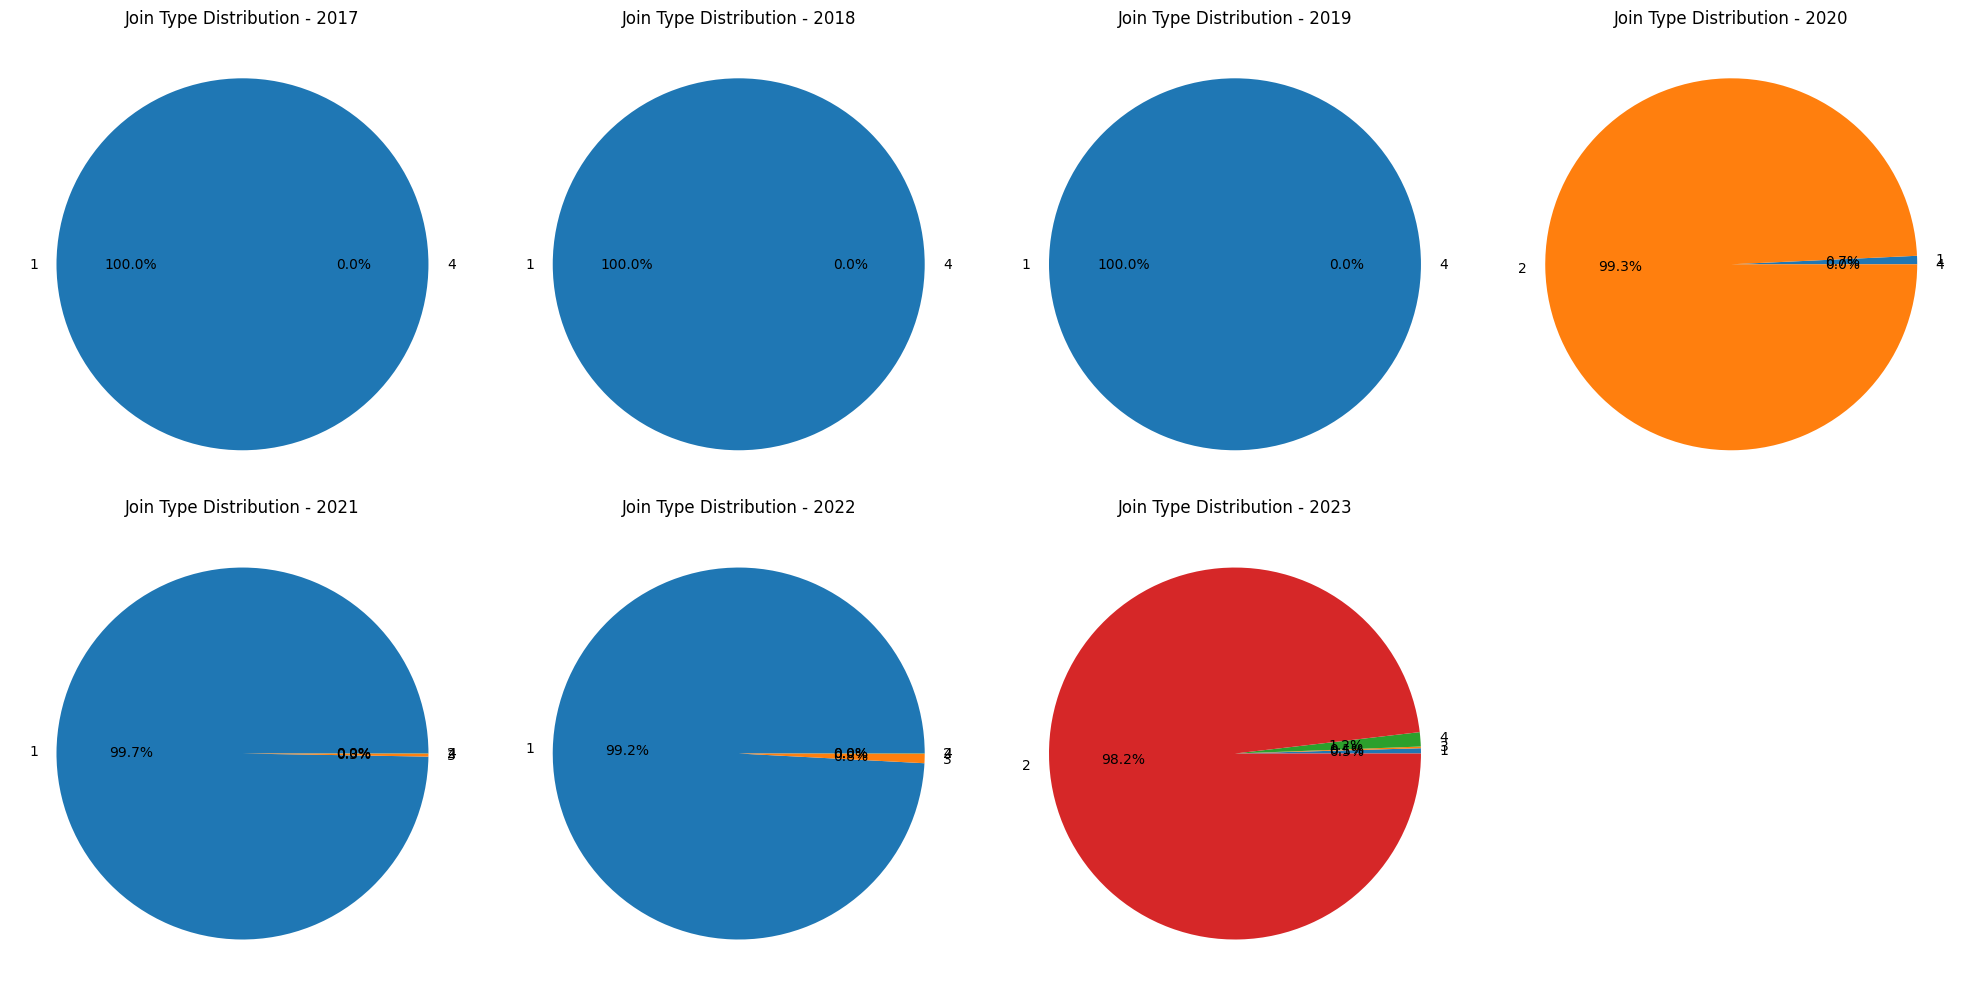

In [ ]:
# Create subplots for each year
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, year in enumerate(YEARS):
    # Filter data for the current year
    year_data = df_grp[df_grp['year'] == year]
    
    # Create pie chart
    axes[i].pie(year_data['sum'], labels=year_data['join_type'], autopct='%1.1f%%')
    axes[i].set_title(f'Join Type Distribution - {year}')

# Hide the last subplot since we have 7 years but 8 subplots
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
# Calculate percentage per year
df_grp['percentage'] = df_grp.groupby('year')['sum'].transform(lambda x: (x / x.sum()) * 100)
df_grp

,join_type,sum,year,percentage
0,1,2.344570e+10,2017,100.000000
1,4,0.000000e+00,2017,0.000000
2,1,2.366671e+10,2018,100.000000
3,4,0.000000e+00,2018,0.000000
4,1,2.401007e+10,2019,100.000000
5,4,0.000000e+00,2019,0.000000
6,1,1.725666e+08,2020,0.728268
7,2,2.352291e+10,2020,99.271732
8,4,0.000000e+00,2020,0.000000
9,1,2.259962e+10,2021,99.735670
